<a href="https://colab.research.google.com/github/Yogita-Kumari/Pystoch-tutorial/blob/main/Pystoch_tut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install all required packages

In [1]:
#Install relevant packages
!pip install -q healpy scipy matplotlib h5py numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 63.7 MB/s eta 0:00:00


In [2]:
import healpy as hp
import scipy
import matplotlib.pyplot as plt
import h5py
import numpy as np

print("All imports successful!")

All imports successful!


# Mount drive such that You can access your files used for tutorial

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Go to folder where all files are

In [4]:
%cd /content/drive/MyDrive/Pystoch_Tut


/content/drive/MyDrive/Pystoch_Tut


In [5]:
!ls

Clean_map		    O2_notch_array_strict_20_1726_0.03125.npy
computeYfandSigmaf_HWI.py   output
convert_frames.py	    parameters.ini
detectors.py		    __pycache__
framesets.ini		    pystoch_full_fisher_pixel.py
Ha23.txt		    pystoch.py
notch_list.txt		    read_frames.py
O2_HL			    run_computeYfandSigmaf_HWI.py
O2-injection-params-O2.txt  tmp


## Check how many cpus are available for multiprocessing and make changes in parameters.ini file

In [6]:
import os
os.cpu_count()

2

# Looking at folded data


In [8]:
folded_data=h5py.File("/content/drive/MyDrive/Pystoch_Tut/O2_HL/IGWN-FoldedData-v1-O2_H1L1_compressed.hdf5",'r')
print(folded_data.keys())
print(folded_data['sigma_sq_inv'][:].shape)
folded_data.close()

<KeysViewHDF5 ['csd', 'gps_times_mid', 'sigma_sq_inv']>
(898, 54593)


# Run pystoch

In [57]:
!python pystoch.py


PyStoch - a Python based code for SGWB mapping.
using parameters from /content/drive/MyDrive/Pystoch_Tut/parameters.ini

Following framesets will be processed. 
 ['O2_HL'] 

 *** processing O2_HL ***
Baseline is H1L1, Total 898 frames of 96 seconds are available

Loading Frame data for 260.0 Hz to 270.0 Hz from following file.
/content/drive/MyDrive/Pystoch_Tut/O2_HL/IGWN-FoldedData-v1-O2_H1L1_compressed.hdf5
CSD and PSD for 321 frequecny bins for range 260.0 Hz to 270.0 Hz loaded.
ORF seeds loaded from following file.
/content/drive/MyDrive/Pystoch_Tut/tmp/seed_maps_O2_HL_1164655053-1164741165-96_nside-16.hdf5
Calculating maps for frequency 260.0 Hz.       
Calculating maps for frequency 260.03125 Hz.       
Calculating maps for frequency 260.0625 Hz.       
Calculating maps for frequency 260.09375 Hz.       
Calculating maps for frequency 260.125 Hz.       
Calculating maps for frequency 260.15625 Hz.       
Calculating maps for frequency 265.03125 Hz.       
Calculating maps for fr

# Plotting dirty map

SNR = dirty map / sqrt(Fisher Matrix)

In [21]:
dirty_map_file=h5py.File('/content/drive/MyDrive/Pystoch_Tut/output/Map_dirty_O2_HL_16_preproc.hdf5')
print(dirty_map_file.keys())
f_all=dirty_map_file['f_all'][:]
fisher_diag=dirty_map_file['fisher_diag'][:]
map_dirty=dirty_map_file['map_dirty'][:]
dirty_map_file.close()

<KeysViewHDF5 ['f_all', 'fisher_diag', 'map_dirty', 'notch_array']>


In [27]:
snr=map_dirty/np.sqrt(fisher_diag)

In [29]:
#Normalization required
seg_duration = 96
df=1/32
winfactor=0.514285060338
bias=1.0503960948183007
norm=2*np.sqrt(seg_duration*df*winfactor)/bias
snr=snr*norm

In [26]:
norm

np.float64(2.3650453828352407)

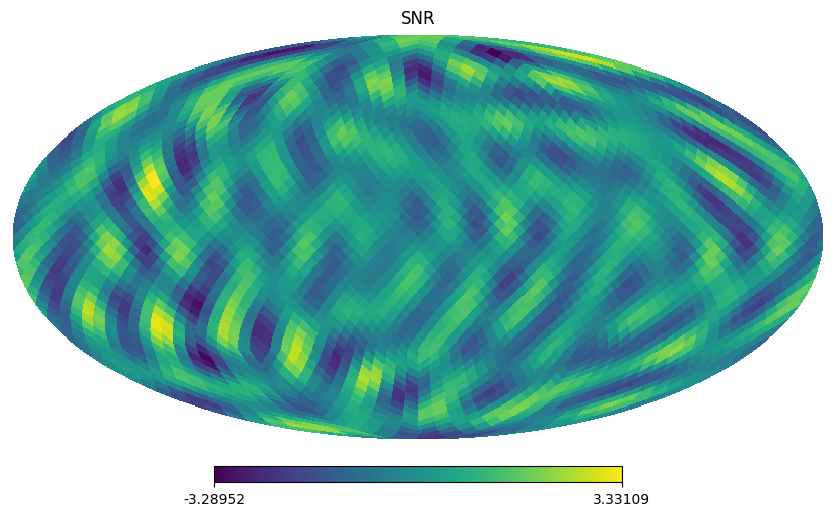

In [30]:
hp.mollview(snr[10], title='SNR')

# Looking at injection

In [31]:
#Index of injection
idx_inj=np.argmin(np.abs(f_all-265.5771052))

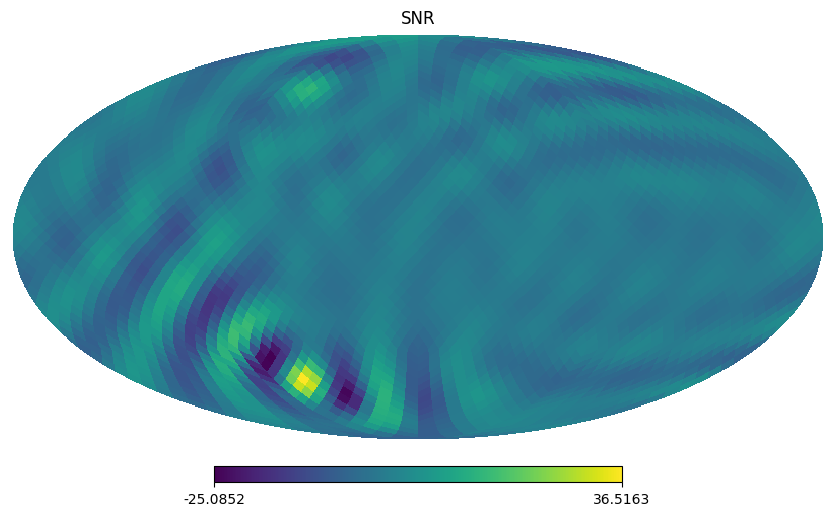

In [32]:
hp.mollview(snr[idx_inj], title='SNR')

In [33]:
#Finding pixel of the source
import pandas as pd
import numpy as np
import healpy as hp

threshold = 1/32
nside=16

df = pd.read_csv(
    "/content/drive/MyDrive/Pystoch_Tut/O2-injection-params-O2.txt",
    sep=r"\s+",
    header=None,
    skiprows=4
)

# frequency
col3 = pd.to_numeric(df.iloc[:, 2], errors="coerce")
# Extract injected sky location (radians)
dec_rad = pd.to_numeric(df.iloc[:, 15], errors="coerce")  # declination
ra_rad  = pd.to_numeric(df.iloc[:, 16], errors="coerce")  # right ascension

# Convert to HEALPix angles
lon_deg = np.rad2deg(ra_rad)   # RA
lat_deg = np.rad2deg(dec_rad)  # Dec

df["pixel"] = hp.ang2pix(nside, lon_deg, lat_deg, lonlat=True)


freq_inj = col3.values

#Corresponding pixels
pixel_inj=df["pixel"].values

print(freq_inj)
print(pixel_inj)



[ 265.5771052   849.0832962   575.163573    108.8571594  1403.163331
   52.80832436  148.7190257  1220.979581    194.3083185   763.8473165
   26.3589129    31.4248598    39.7276097    12.43       1991.0926    ]
[2769 2278 1478 2368 1874 3066 2927 2055 2462   51  519 2883 2011 1122
 1941]


In [34]:
pixel=pixel_inj[np.argmin(np.abs(freq_inj-265.5771052))]

/usr/local/lib/python3.12/dist-packages/healpy/projector.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  img[w] = mpix


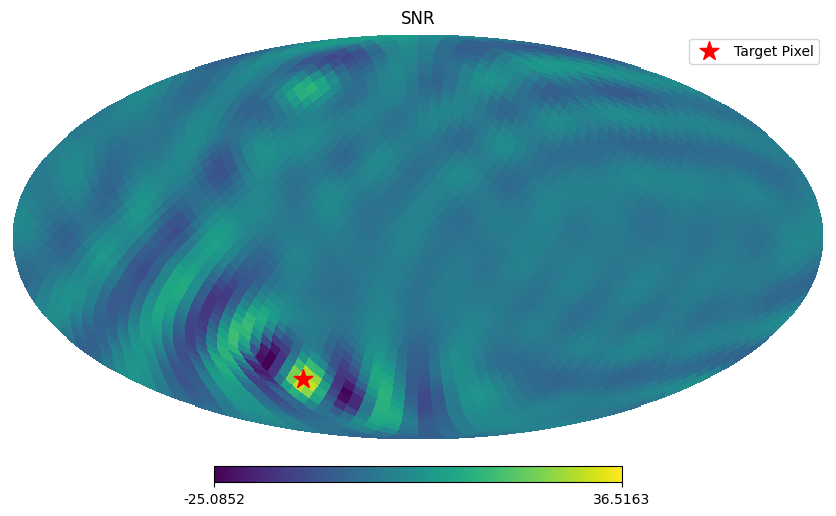

In [35]:
# 1. Extract your 1D spatial HEALPix map slice
current_map = snr[idx_inj]

# 2. Plot your map
hp.mollview(current_map, title='SNR')

# 3. Define the pixel you want to mark
target_pixel = pixel  # e.g., 2769

# 4. Get the NSIDE from the actual spatial map array
nside = hp.get_nside(current_map)

# 5. Convert the pixel index to angular coordinates (theta, phi) in radians
theta, phi = hp.pix2ang(nside, target_pixel)

# 6. Project and scatter the star onto the Mollweide view
hp.projscatter(theta, phi, marker='*', color='red', s=200, label='Target Pixel')

# Optional: Add a legend and show the plot
plt.legend()
plt.show()

# Extra (not required to do)

# Getting clean map

In [69]:
!python run_computeYfandSigmaf_HWI.py

PostProcessing Starts for O2_HL Baseline
/content/drive/MyDrive/Pystoch_Tut/computeYfandSigmaf_HWI.py:50: UserWarning: Input line 5 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  pulsar_inj=np.loadtxt(injParamsFile,dtype='str',skiprows=4)
PostProcessing Done for O2_HL Baseline


In [36]:
clean_map = h5py.File('/content/drive/MyDrive/Pystoch_Tut/Clean_map/Map_ASAF_HL_16_postproc_with_HWI.hdf5','r')
snr=clean_map['snr'][:]
print(list(clean_map.keys()))
clean_map.close()

['f_all', 'notch_aray', 'ptEst', 'sig', 'snr']


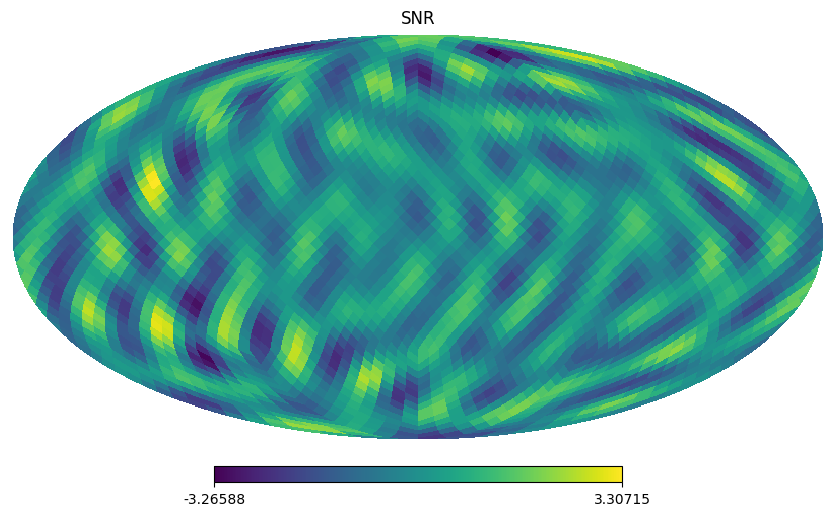

In [37]:
hp.mollview(snr[10], title='SNR')

# Looking at injections

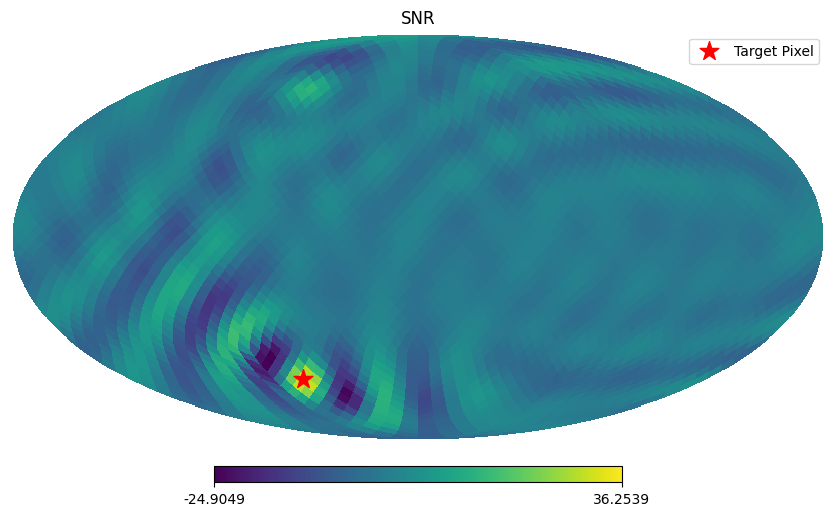

In [38]:
# 1. Extract your 1D spatial HEALPix map slice
current_map = snr[idx_inj]

# 2. Plot your map
hp.mollview(current_map, title='SNR')

# 3. Define the pixel you want to mark
target_pixel = pixel  # e.g., 2769

# 4. Get the NSIDE from the actual spatial map array
nside = hp.get_nside(current_map)

# 5. Convert the pixel index to angular coordinates (theta, phi) in radians
theta, phi = hp.pix2ang(nside, target_pixel)

# 6. Project and scatter the star onto the Mollweide view
hp.projscatter(theta, phi, marker='*', color='red', s=200, label='Target Pixel')

# Optional: Add a legend and show the plot
plt.legend()
plt.show()